# Continuous Kantorovich dual potentials

This notebook generates `fig:dual-kantorovich-continuous-potentials`.  For the one-dimensional quadratic cost
$$
    c(x,y)=|x-y|^2,
$$
the optimal map is the monotone rearrangement $T=F_\beta^{-1}\circ F_\alpha$.  Along the support of the optimal plan,
$$
    f'(x)=\partial_x c(x,T(x))=2(x-T(x)),
    \qquad g=f^c.
$$
The panels show the smooth analogue of the discrete dual-potential certificates from `fig:dual-kantorovich-discrete-potentials`.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from figure_style import (
    RED, BLUE, VIOLET, GRAY, LIGHT_GRAY,
    DIRAC_MARKER_SIZE, setup_matplotlib, figure_dir, save_pdf, box_axes,
)

setup_matplotlib()

## Smooth densities, monotone map, and hard `c`-transform

The potentials are not obtained by a heavy optimization.  In one dimension the optimal quadratic map is read from quantiles.  We integrate $2(x-T(x))$ to obtain $f$, then compute $g=f^c$ on the same fine grid.

In [2]:
NAME = "dual-kantorovich-continuous-potentials"
OUT = figure_dir(NAME)

grid = np.linspace(-2.75, 2.75, 560)
dx = grid[1] - grid[0]


def gaussian_mixture_density(x, weights, means, stds):
    x = np.asarray(x)
    density = np.zeros_like(x, dtype=float)
    for w, m, s in zip(weights, means, stds):
        density += w * np.exp(-0.5 * ((x - m) / s) ** 2) / (s * np.sqrt(2 * np.pi))
    density /= np.trapezoid(density, x)
    return density


def cdf_from_density(density):
    increments = 0.5 * (density[:-1] + density[1:]) * np.diff(grid)
    cdf = np.r_[0.0, np.cumsum(increments)]
    cdf /= cdf[-1]
    cdf = np.maximum.accumulate(cdf)
    return cdf


def cumulative_trapezoid(values):
    increments = 0.5 * (values[:-1] + values[1:]) * np.diff(grid)
    return np.r_[0.0, np.cumsum(increments)]


def potentials_from_quantiles(alpha_density, beta_density):
    Fa = cdf_from_density(alpha_density)
    Fb = cdf_from_density(beta_density)
    quantile_levels = np.clip(Fa, 1e-5, 1.0 - 1e-5)
    T = np.interp(quantile_levels, Fb, grid)
    fp = 2.0 * (grid - T)
    f = cumulative_trapezoid(fp)
    f -= np.trapezoid(f * alpha_density, grid)
    C = (grid[:, None] - grid[None, :]) ** 2
    g = np.min(C - f[:, None], axis=0)
    shift = np.trapezoid(f * alpha_density, grid)
    f = f - shift
    g = g + shift
    return f, g, T

source_params = dict(weights=[1.0], means=[0.0], stds=[0.56])
targets = [
    ("balanced", dict(weights=[0.50, 0.50], means=[-1.15, 1.12], stds=[0.24, 0.24])),
    ("shifted", dict(weights=[0.24, 0.76], means=[-0.58, 1.52], stds=[0.24, 0.31])),
    ("three-mode", dict(weights=[0.34, 0.38, 0.28], means=[-1.48, 0.10, 1.58], stds=[0.21, 0.34, 0.19])),
]

alpha_density = gaussian_mixture_density(grid, **source_params)
solutions = []
for tag, params in targets:
    beta_density = gaussian_mixture_density(grid, **params)
    f, g, T = potentials_from_quantiles(alpha_density, beta_density)
    solutions.append((tag, beta_density, f, g, T))

all_potentials = np.concatenate([np.r_[f, g] for _, _, f, g, _ in solutions])
ymin, ymax = np.percentile(all_potentials, [1, 99])
margin = 0.12 * (ymax - ymin)
ylim_potential = (ymin - margin, ymax + margin)
max_density = max(alpha_density.max(), *(beta_density.max() for _, beta_density, _, _, _ in solutions))

## Exported panels

The top strip displays the source density above the axis and the target density below it.  The bottom axis displays the continuous potentials after a fixed gauge shift.

In [3]:
def draw_panel(tag, beta_density, f, g):
    fig = plt.figure(figsize=(2.36, 1.96))
    gs = fig.add_gridspec(2, 1, height_ratios=[0.62, 1.0], hspace=0.08)
    ax_m = fig.add_subplot(gs[0, 0])
    ax_p = fig.add_subplot(gs[1, 0], sharex=ax_m)

    ax_m.fill_between(grid, 0.0, alpha_density, color=RED, alpha=0.25, linewidth=0)
    ax_m.fill_between(grid, 0.0, -beta_density, color=BLUE, alpha=0.25, linewidth=0)
    ax_m.plot(grid, alpha_density, color=RED, lw=0.82)
    ax_m.plot(grid, -beta_density, color=BLUE, lw=0.82)
    ax_m.axhline(0, color="#777777", lw=0.45)
    ax_m.set_xlim(grid.min(), grid.max())
    ax_m.set_ylim(-1.08 * max_density, 1.08 * max_density)
    ax_m.tick_params(labelbottom=False, labelleft=False, length=0)
    box_axes(ax_m)

    ax_p.plot(grid, f, color=RED, lw=1.18)
    ax_p.plot(grid, g, color=BLUE, lw=1.18)
    ax_p.axhline(0, color=LIGHT_GRAY, lw=0.55, zorder=0)
    ax_p.set_xlim(grid.min(), grid.max())
    ax_p.set_ylim(*ylim_potential)
    ax_p.tick_params(labelbottom=False, labelleft=False, length=0)
    box_axes(ax_p)

    save_pdf(fig, OUT / f"target-{tag}.pdf", pad_inches=0.035)
    plt.close(fig)

for tag, beta_density, f, g, T in solutions:
    draw_panel(tag, beta_density, f, g)

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


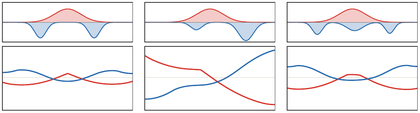

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/dual-kantorovich-continuous-potentials.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/dual-kantorovich-continuous-potentials.png")
display(Image(filename=str(_thumb)))
